# Lifestyle Phenotypes and Insomnia Prediction in US Adults
**Milestone 2 Master Notebook**


Project description:

Table of contents:



## Metabolic Syndrome (MetS)

Metabolic Syndrome is a clinically defined cluster of cardiometabolic risk factors that together significantly increase the risk of type 2 diabetes, cardiovascular disease, and related conditions. Diagnosis requires **any 3 of the following 5 harmonised criteria** (IDF/AHA/NHLBI 2009 consensus):

| Criterion | Threshold |
|---|---|
| Abdominal obesity | Elevated waist circumference (population-specific cut-offs) |
| High triglycerides | ≥ 150 mg/dL |
| Low HDL cholesterol | < 40 mg/dL (men), < 50 mg/dL (women) |
| High blood pressure | ≥ 130 systolic or ≥ 85 diastolic mmHg |
| High fasting glucose | ≥ 100 mg/dL |

This panel directly informs our clustering feature set. Rather than diagnosing MetS as a binary outcome, we use the underlying continuous biomarkers as input to k-means, allowing the model to identify distinct metabolic phenotypes within the population. These phenotype labels are then introduced as engineered features in the supervised model to test whether metabolic subgroup membership improves prediction of sleep problems beyond standard covariates.

P_BIOPRO: Standard Biochemistry Profile

P_BIOPRO contains 41 serum chemistry variables across 10,409 participants — the largest sample of any lab file in the pre-pandemic release. We extract three variables as extended (Tier 2) metabolic features:

- **LBXSUA (Uric Acid):** elevated uric acid (hyperuricemia) is independently associated with insulin resistance, hypertension, and metabolic syndrome, and has been linked to poor sleep quality and obstructive sleep apnoea.
- **LBXSATSI (ALT):** primary clinical marker of non-alcoholic fatty liver disease (NAFLD), which is recognised as the hepatic manifestation of metabolic syndrome.
- **LBXSGTSI (GGT):** liver enzyme sensitive to early metabolic dysfunction and oxidative stress, independently associated with insulin resistance even without significant alcohol use.

These three markers allow the k-means model to surface a liver/inflammation-driven phenotype that the five harmonised MetS criteria alone would not separate out.

## Dataset Loading & Cleaning

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import os
from functools import reduce
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from umap import UMAP



In [87]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


data_path_candidates = [
    Path.cwd() / "data",
    Path("/content/drive/MyDrive/Milestone 2/data"),
    Path("/content/drive/MyDrive/") / "data" # Added to correctly locate data in MyDrive
]

base_path = next((path for path in data_path_candidates if path.exists()), None)

if base_path is None:
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=True)
        base_path = next((path for path in data_path_candidates if path.exists()), None)
    except ModuleNotFoundError:
        pass

if base_path is None:
    raise FileNotFoundError("Could not find the NHANES data folder. Update data_path_candidates above.")

category_paths = {
    "Lab": base_path / "Lab",
    "Questionnaire": base_path / "Questionnaire",
    "Demographic": base_path / "Demographic",
    "Examination": base_path / "Examination",
}

missing_folders = [name for name, path in category_paths.items() if not path.exists()]
if missing_folders:
    raise FileNotFoundError(f"Missing expected data folders: {missing_folders}")

print(f"Using data folder: {base_path}")

Mounted at /content/drive
Using data folder: /content/drive/MyDrive/Milestone 2/data


In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
# Selected NHANES files and friendly names used in this project.
lab_file_descriptions = {
    "P_GHB.xpt": "Glycohemoglobin",
    "P_GLU.xpt": "Fasting Glucose",
    "P_HDL.xpt": "HDL Cholesterol",
    "P_HSCRP.xpt": "High-Sensitivity C-Reactive Protein",
    "P_INS.xpt": "Insulin",
    "P_TCHOL.xpt": "Total Cholesterol",
    "P_TRIGLY.xpt": "Triglycerides",
    "P_BIOPRO.xpt": "Standard Biochemistry Profile",
    "P_FASTQX.xpt": "Fasting Questionnaire",
}

questionnaire_file_descriptions = {
    "P_PAQ.xpt": "Physical Activity Questionnaire",
    "P_DBQ.xpt": "Dietary Behavior Questionnaire",
    "P_DIQ.xpt": "Diabetes Questionnaire",
    "P_BPQ.xpt": "Blood Pressure and Cholesterol Questionnaire",
    "P_SMQ.xpt": "Smoking Questionnaire",
    "P_SLQ.xpt": "Sleep Disorders Questionnaire",
    "P_MCQ.xpt": "Medical Conditions Questionnaire",
    "P_ALQ.xpt": "Alcohol Use Questionnaire",
    "P_DPQ.xpt": "Depression Screener (PHQ-9)",
}

demographic_file_descriptions = {
    "P_DEMO.xpt": "Demographics",
}

examination_file_descriptions = {
    "P_BMX.xpt": "Body Measures",
    "P_BPXO.xpt": "Blood Pressure - Oscillometric Measurement",
}

# Raw NHANES names are keys; analysis-friendly names are values.
column_names = {
    # Demographics
    "SEQN": "ID",
    "RIDAGEYR": "Age",
    "RIAGENDR": "Sex",
    "SDDSRVYR": "Survey Cycle",

    # Physical activity
    "PAQ605": "Vigorous Work Activity",
    "PAQ610": "Vigorous Work Days",
    "PAD615": "Vigorous Work Minutes",
    "PAQ620": "Moderate Work Activity",
    "PAQ625": "Moderate Work Days",
    "PAD630": "Moderate Work Minutes",
    "PAQ635": "Walk or Bicycle for Transportation",
    "PAQ640": "Walk/Bicycle Days",
    "PAD645": "Walk/Bicycle Minutes",
    "PAQ650": "Vigorous Recreational Activity",
    "PAQ655": "Vigorous Recreational Days",
    "PAD660": "Vigorous Recreational Minutes",
    "PAQ665": "Moderate Recreational Activity",
    "PAQ670": "Moderate Recreational Days",
    "PAD675": "Moderate Recreational Minutes",
    "PAD680": "Sedentary Minutes",

    # Core metabolic biomarkers
    "LBXGH": "Glycohemoglobin (%)",
    "LBXGLU": "Fasting Glucose (mg/dL)",
    "LBXIN": "Insulin (µU/mL)",
    "LBDHDD": "HDL Cholesterol (mg/dL)",
    "LBXTC": "Total Cholesterol (mg/dL)",
    "LBXTR": "Triglycerides (mg/dL)",
    "LBXHSCRP": "HS C-Reactive Protein (mg/L)",

    # Extended metabolic markers
    "LBXSUA": "Uric Acid (mg/dL)",
    "LBXSATSI": "ALT (U/L)",
    "LBXSGTSI": "GGT (U/L)",

    # Body measures
    "BMXBMI": "BMI (kg/m^2)",
    "BMXWAIST": "Waist Circumference (cm)",

    # Blood pressure readings
    "BPXOSY1": "Systolic BP 1 (mmHg)",
    "BPXOSY2": "Systolic BP 2 (mmHg)",
    "BPXOSY3": "Systolic BP 3 (mmHg)",
    "BPXODI1": "Diastolic BP 1 (mmHg)",
    "BPXODI2": "Diastolic BP 2 (mmHg)",
    "BPXODI3": "Diastolic BP 3 (mmHg)",

    # Sleep
    "SLQ300": "Weekday Sleep Time",
    "SLQ310": "Weekday Wake Time",
    "SLD012": "Weekday Sleep Hours",
    "SLQ320": "Weekend Sleep Time",
    "SLQ330": "Weekend Wake Time",
    "SLD013": "Weekend Sleep Hours",
    "SLQ030": "Snoring Frequency",
    "SLQ040": "Stop Breathing During Sleep Frequency",
    "SLQ050": "Doctor Told Trouble Sleeping",
    "SLQ120": "Daytime Sleepiness Frequency",


    "WTSAFPRP": "Fasting Weight",
    "WTMECPRP": "MEC Weight",
    "SDMVPSU": "PSU",
    "SDMVSTRA": "Stratum",
}

## Step 1: Data Cleaning

In [90]:
def convert_to_df(folder_path, filename):
    """Read one NHANES XPT file into a DataFrame."""
    file_path = Path(folder_path) / filename
    return pd.read_sas(file_path, format="xport")


def load_selected_files(folder_path, file_descriptions, category_name):
    """Load the selected files for one NHANES category and print readable progress."""
    dataframes = []
    missing_files = []

    for index, (filename, friendly_name) in enumerate(file_descriptions.items(), start=1):
        file_path = Path(folder_path) / filename

        if not file_path.exists():
            missing_files.append(filename)
            continue

        df = convert_to_df(folder_path, filename)
        dataframes.append(df)
        print(f"{category_name} DataFrame {index}: {friendly_name} ({filename}) {df.shape}")

    if missing_files:
        print(f"Missing {category_name} files: {missing_files}")

    return dataframes


lab_df_list = load_selected_files(category_paths["Lab"], lab_file_descriptions, "Lab")
questionnaire_df_list = load_selected_files(
    category_paths["Questionnaire"],
    questionnaire_file_descriptions,
    "Questionnaire",
)
demographic_df_list = load_selected_files(
    category_paths["Demographic"],
    demographic_file_descriptions,
    "Demographic",
)
examination_df_list = load_selected_files(
    category_paths["Examination"],
    examination_file_descriptions,
    "Examination",
)



Lab DataFrame 1: Glycohemoglobin (P_GHB.xpt) (10409, 2)
Lab DataFrame 2: Fasting Glucose (P_GLU.xpt) (5090, 4)
Lab DataFrame 3: HDL Cholesterol (P_HDL.xpt) (12198, 3)
Lab DataFrame 4: High-Sensitivity C-Reactive Protein (P_HSCRP.xpt) (13772, 3)
Lab DataFrame 5: Insulin (P_INS.xpt) (5090, 5)
Lab DataFrame 6: Total Cholesterol (P_TCHOL.xpt) (12198, 3)
Lab DataFrame 7: Triglycerides (P_TRIGLY.xpt) (5090, 10)
Lab DataFrame 8: Standard Biochemistry Profile (P_BIOPRO.xpt) (10409, 41)
Lab DataFrame 9: Fasting Questionnaire (P_FASTQX.xpt) (13772, 19)
Questionnaire DataFrame 1: Physical Activity Questionnaire (P_PAQ.xpt) (9693, 17)
Questionnaire DataFrame 2: Dietary Behavior Questionnaire (P_DBQ.xpt) (15560, 46)
Questionnaire DataFrame 3: Diabetes Questionnaire (P_DIQ.xpt) (14986, 28)
Questionnaire DataFrame 4: Blood Pressure and Cholesterol Questionnaire (P_BPQ.xpt) (10195, 11)
Questionnaire DataFrame 5: Smoking Questionnaire (P_SMQ.xpt) (11137, 16)
Questionnaire DataFrame 6: Sleep Disorders Q

Load + Merge: Lab, Questionaire, Demographic and Examination Files

In [91]:
def merge_on_participant_id(dataframes, id_col="SEQN"):
    """Merge NHANES DataFrames on the participant identifier.
    Drops duplicate non-ID columns from later files before each outer merge.
    """
    dataframes = [df for df in dataframes if id_col in df.columns]
    print(f"DataFrames with {id_col}:", len(dataframes))

    if not dataframes:
        raise ValueError(f"No loaded DataFrames contain {id_col}, so the files cannot be merged.")

    merged_df = dataframes[0].copy()

    for df in dataframes[1:]:
        overlap_cols = merged_df.columns.intersection(df.columns).drop(id_col, errors="ignore")
        merged_df = merged_df.merge(df.drop(columns=overlap_cols), on=id_col, how="outer")

    return merged_df


all_df_list = demographic_df_list + questionnaire_df_list + lab_df_list + examination_df_list
master_df = merge_on_participant_id(all_df_list)

print("Master dataframe shape:", master_df.shape)
master_df.head()

DataFrames with SEQN: 21
Master dataframe shape: (15560, 344)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,...,3.0,109.0,67.0,109.0,68.0,106.0,66.0,94.0,95.0,91.0
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,4.0,99.0,56.0,99.0,55.0,99.0,52.0,68.0,66.0,66.0
4,109267.0,66.0,1.0,2.0,21.0,NaN,2.0,2.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
[c for c in master_df.columns if 'WTSAF' in c or 'WTMEC' in c]

['WTMECPRP', 'WTSAFPRP']

In [93]:
def create_analysis_dataframe(master_df, column_names):
    """Select project columns and apply friendly names.
    Cleans core demographic types while preserving the full master_df upstream.
    """
    analysis_cols = [col for col in column_names if col in master_df.columns]
    missing_cols = [col for col in column_names if col not in master_df.columns]

    analysis_df = master_df.loc[:, analysis_cols].copy()
    analysis_df.rename(columns=column_names, inplace=True)

    if "Sex" in analysis_df.columns:
        analysis_df["Sex"] = analysis_df["Sex"].map({1.0: "Male", 2.0: "Female"})

    for col in ["ID", "Age"]:
        if col in analysis_df.columns:
            analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce").round().astype("Int64")

    analysis_df.reset_index(drop=True, inplace=True)
    return analysis_df, analysis_cols, missing_cols


analysis_df, analysis_cols, missing_cols = create_analysis_dataframe(master_df, column_names)

print(f"Kept {len(analysis_cols)} columns out of {master_df.shape[1]} total columns.")

if missing_cols:
    print("Columns not found in master_df:")
    print(missing_cols)

analysis_df.head()




Kept 52 columns out of 344 total columns.


,ID,Age,Sex,Survey Cycle,Vigorous Work Activity,Vigorous Work Days,Vigorous Work Minutes,Moderate Work Activity,Moderate Work Days,Moderate Work Minutes,...,Weekend Wake Time,Weekend Sleep Hours,Snoring Frequency,Stop Breathing During Sleep Frequency,Doctor Told Trouble Sleeping,Daytime Sleepiness Frequency,Fasting Weight,MEC Weight,PSU,Stratum
0,109263,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.951816e+03,3.0,156.0
1,109264,13,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27533.174559,1.227116e+04,1.0,155.0
2,109265,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.665876e+04,1.0,157.0
3,109266,29,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'07:00',8.0,1.000000e+00,5.397605e-79,2.0,5.397605e-79,NaN,8.154968e+03,2.0,168.0
4,109267,21,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'11:00',8.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,NaN,5.397605e-79,1.0,156.0


In [94]:
# Clean survey weight columns.
# Some SAS/XPT zero values may be read by pandas as extremely tiny positive values.
# Treat anything effectively zero as true zero.

survey_weight_cols = ["Fasting Weight", "MEC Weight"]

for col in survey_weight_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")
        analysis_df.loc[analysis_df[col] < 1e-12, col] = 0.0

In [95]:
# Step 6: Cap highly skewed numeric analysis columns at the 99th percentile.

def cap_columns_at_quantile(df, columns, quantile=0.99):
    """Cap selected columns at a chosen upper quantile.
    Returns the capped DataFrame and the list of columns that were found.
    """
    existing_cols = [col for col in columns if col in df.columns]

    for col in existing_cols:
        upper_limit = df[col].quantile(quantile)
        df[col] = df[col].clip(upper=upper_limit)

    return df, existing_cols


columns_to_cap = [
    "Fasting Glucose (mg/dL)",
    "Glycohemoglobin (%)",
    "HDL Cholesterol (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "Triglycerides (mg/dL)",
    "Insulin (µU/mL)",
    "HS C-Reactive Protein (mg/L)",
    "Uric Acid (mg/dL)",
    "ALT (U/L)",
    "GGT (U/L)",
    "BMI (kg/m^2)",
    "Waist Circumference (cm)",
    "Sedentary Minutes",
    "Moderate_Weekly_Minutes",
    "Vigorous_Weekly_Minutes",
    "Total_Weekly_Mins",
    "Total_MVPA_Equivalent_Mins",
]

analysis_df, capped_cols = cap_columns_at_quantile(analysis_df, columns_to_cap)

print("Capped columns:")
print(capped_cols)

Capped columns:
['Fasting Glucose (mg/dL)', 'Glycohemoglobin (%)', 'HDL Cholesterol (mg/dL)', 'Total Cholesterol (mg/dL)', 'Triglycerides (mg/dL)', 'Insulin (µU/mL)', 'HS C-Reactive Protein (mg/L)', 'Uric Acid (mg/dL)', 'ALT (U/L)', 'GGT (U/L)', 'BMI (kg/m^2)', 'Waist Circumference (cm)', 'Sedentary Minutes']


## Feature Engineering for Modeling

The next cells create a clean modeling table from the cleaned `analysis_df`.

In [96]:
def normalize_tiny_zero_artifacts(df, threshold=1e-12):
    """Convert tiny SAS XPORT zero artifacts into true zeros.
    Leaves nonnumeric columns unchanged and returns a cleaned copy.
    """
    cleaned_df = df.copy()
    numeric_cols = cleaned_df.select_dtypes(include="number").columns
    cleaned_df[numeric_cols] = cleaned_df[numeric_cols].mask(cleaned_df[numeric_cols].abs() < threshold, 0)
    return cleaned_df


def make_binary_response(series, yes_value=1, no_value=2):
    """Convert standard NHANES yes/no responses into 1/0 values.
    Codes other than yes or no are treated as missing.
    """
    numeric = pd.to_numeric(series, errors="coerce").replace({7: np.nan, 9: np.nan})
    return numeric.map({yes_value: 1, no_value: 0}).astype("Int64")

In [97]:
#

In [98]:
analysis_df

,ID,Age,Sex,Survey Cycle,Vigorous Work Activity,Vigorous Work Days,Vigorous Work Minutes,Moderate Work Activity,Moderate Work Days,Moderate Work Minutes,...,Weekend Wake Time,Weekend Sleep Hours,Snoring Frequency,Stop Breathing During Sleep Frequency,Doctor Told Trouble Sleeping,Daytime Sleepiness Frequency,Fasting Weight,MEC Weight,PSU,Stratum
0,109263,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8951.815567,3.0,156.0
1,109264,13,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27533.174559,12271.157043,1.0,155.0
2,109265,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16658.764203,1.0,157.0
3,109266,29,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'07:00',8.0,1.000000e+00,5.397605e-79,2.0,5.397605e-79,NaN,8154.968193,2.0,168.0
4,109267,21,Female,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'11:00',8.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,NaN,0.000000,1.0,156.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15555,124818,40,Male,66.0,2.0,NaN,NaN,2.0,NaN,NaN,...,b'08:00',7.0,3.000000e+00,5.397605e-79,2.0,2.000000e+00,NaN,21666.889837,1.0,166.0
15556,124819,2,Male,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1838.169709,2.0,171.0
15557,124820,7,Female,66.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16497.806674,1.0,157.0
15558,124821,63,Male,66.0,1.0,1.0,10.0,2.0,NaN,NaN,...,b'09:00',9.0,5.397605e-79,5.397605e-79,2.0,2.000000e+00,10704.467871,4853.430230,1.0,158.0


In [99]:
[col for col in analysis_df.columns if any(word in col for word in ["Sleep", "Snoring", "Breathing", "Daytime"])]

['Weekday Sleep Time',
 'Weekday Sleep Hours',
 'Weekend Sleep Time',
 'Weekend Sleep Hours',
 'Snoring Frequency',
 'Stop Breathing During Sleep Frequency',
 'Doctor Told Trouble Sleeping',
 'Daytime Sleepiness Frequency']

Features we should engineer/include:

- Demographics: Age, Sex
- Physical activity: Moderate_Weekly_Minutes, Vigorous_Weekly_Minutes, Total_Weekly_Mins, Total_MVPA_Equivalent_Mins, Meets_Goal, Sedentary Minutes

- Sleep outcome/features: Doctor Told Sleep Disorder, Weekday Sleep Hours, Weekend Sleep Hours, possibly engineered Average Sleep Hours, Short Sleep, Long Sleep

- Metabolic biomarkers: Fasting Glucose (mg/dL), Glycohemoglobin (%), Insulin (µU/mL), HDL Cholesterol (mg/dL), Total Cholesterol (mg/dL), Triglycerides (mg/dL), HS C-Reactive Protein (mg/L)
Extended metabolic/liver markers: Uric Acid (mg/dL), ALT (U/L), GGT (U/L)

- Body measures: BMI (kg/m^2), Waist Circumference (cm)
- Blood pressure: Systolic BP 1/2/3, Diastolic BP 1/2/3, plus engineered Average Systolic BP, Average Diastolic BP

- Questionnaire covariates: Doctor Told Diabetes, Ever Told High Blood Pressure, and PHQ depression symptoms excluding the sleep item

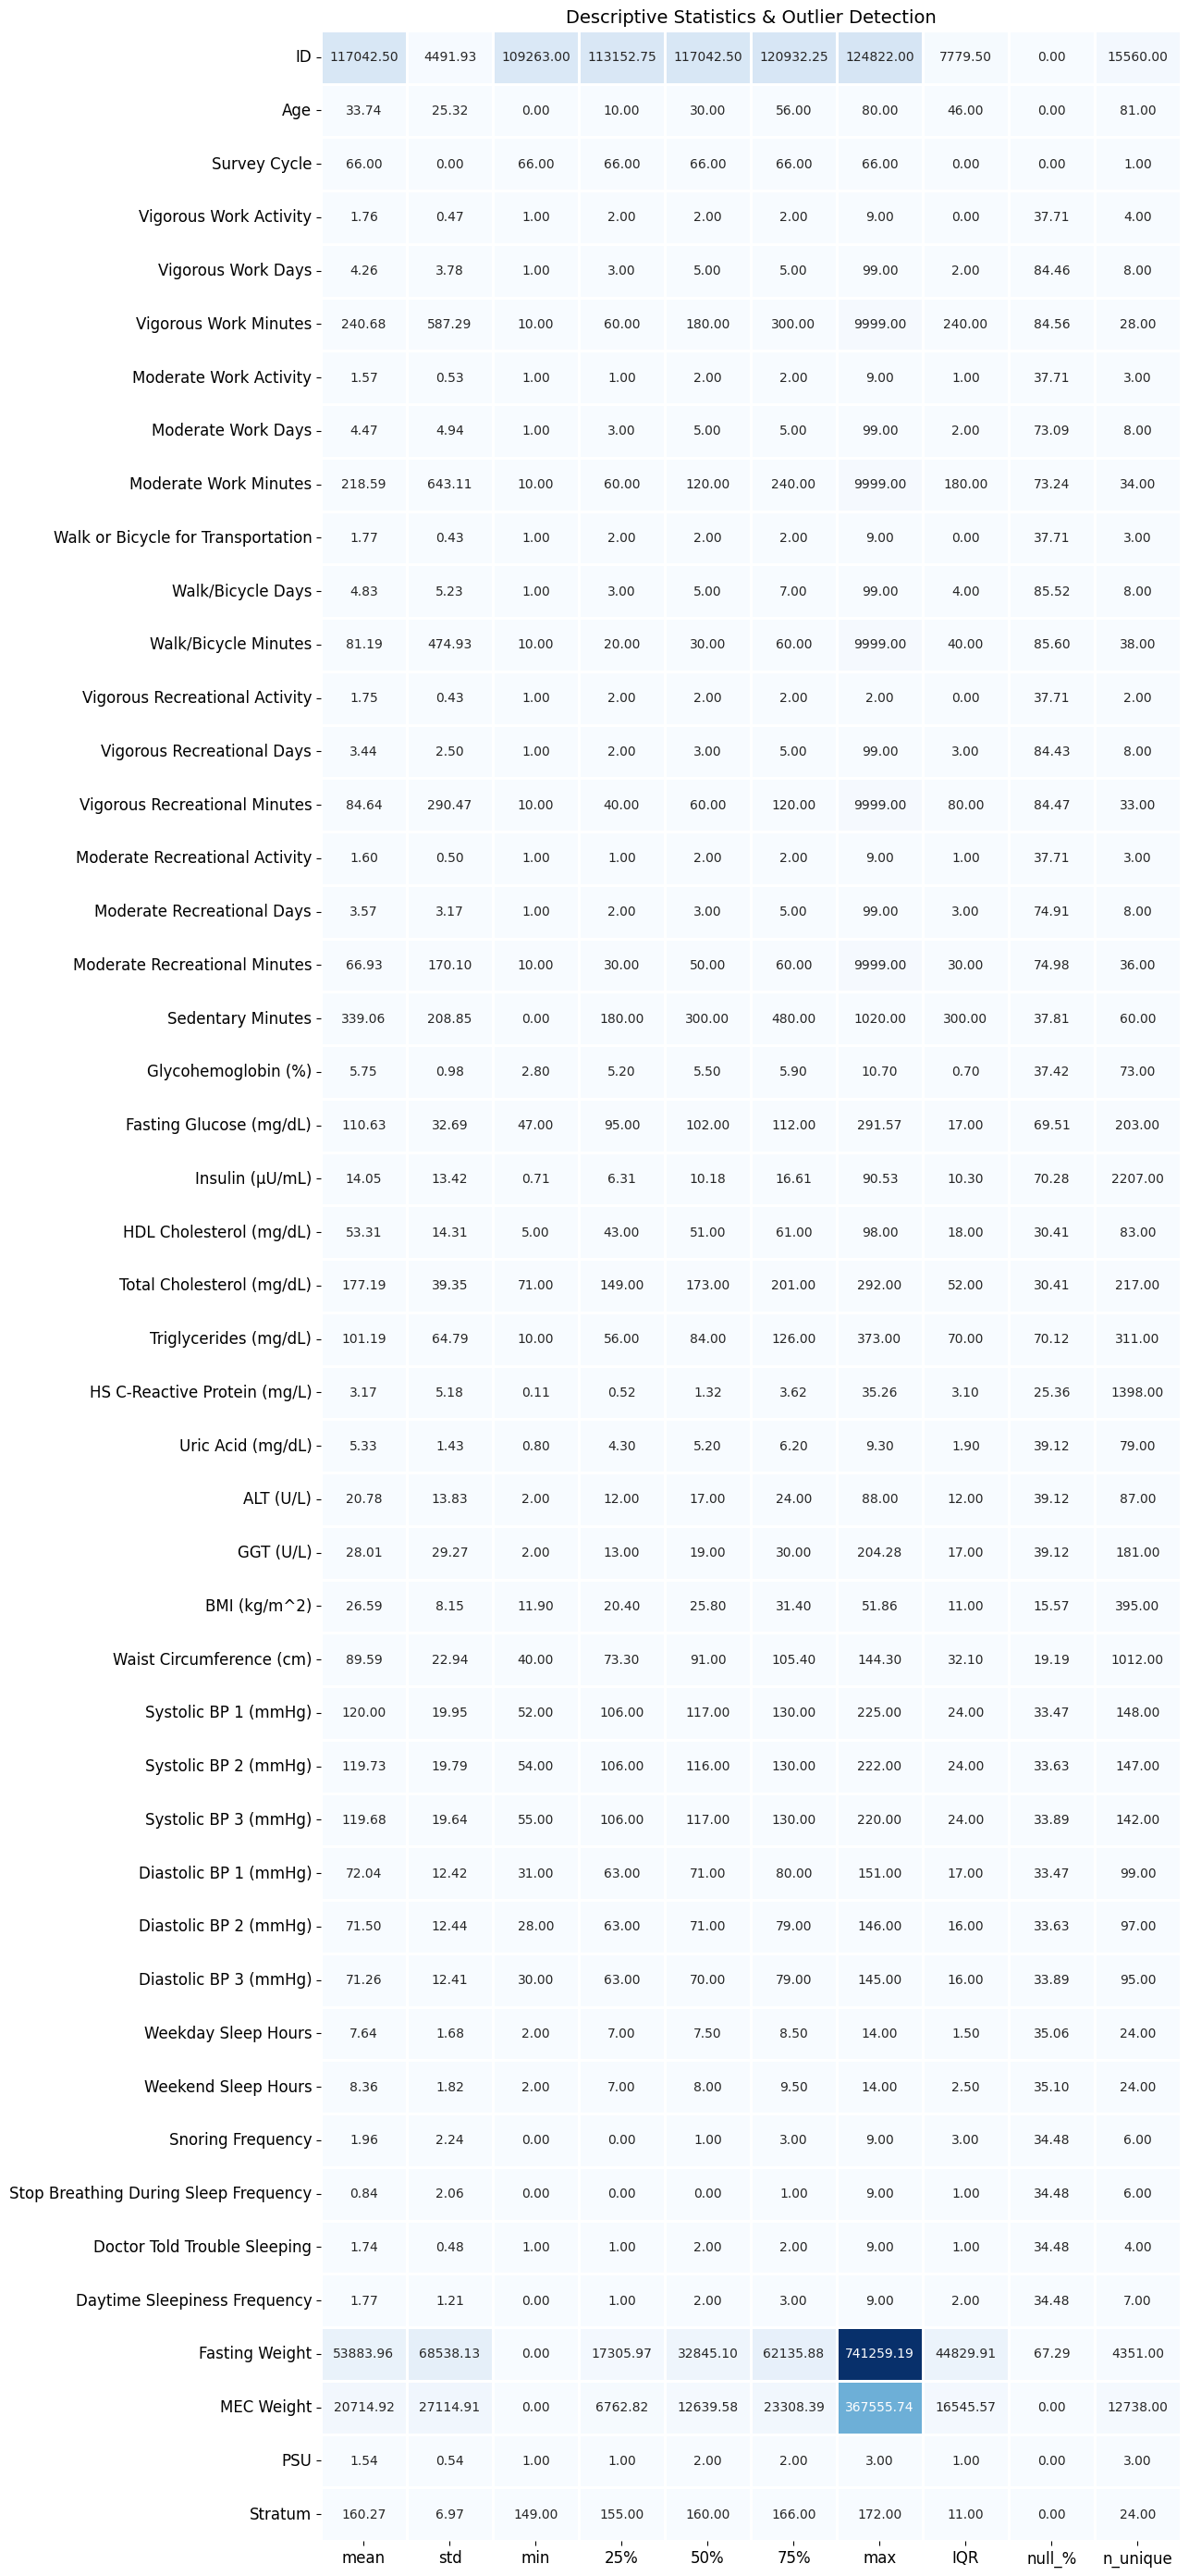

In [100]:
def analyze_df(df, include_corr=False, return_summary=False):
    """
    Analyze a numeric DataFrame: summarize statistics, detect outliers, and visualize via heatmap.

    Parameters:
    - df: pandas DataFrame with only numerical columns
    - include_corr: if True, displays a correlation heatmap
    - return_summary: if True, returns the summary DataFrame

    Returns:
    - summary DataFrame
    """
    # Validate input
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame.")

    numeric_df = df.select_dtypes(include=[float, int])
    if numeric_df.empty:
        raise ValueError("No numeric columns found in the DataFrame.")

    desc = numeric_df.describe().T

    # Compute IQR and outlier bounds
    desc['IQR'] = desc['75%'] - desc['25%']
    desc['null_%'] = (numeric_df.isnull().sum()/len(numeric_df)) * 100
    desc['n_unique'] = numeric_df.nunique()
    desc['max_outlier'] = numeric_df.max() > (desc['75%'] + 1.5 * desc['IQR'])
    desc['min_outlier'] = numeric_df.min() < (desc['25%'] - 1.5 * desc['IQR'])

    # Select relevant columns for visualization
    vis_df = desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'null_%', 'n_unique']].astype(float)

    # Plot heatmap
    plt.figure(figsize=(12, vis_df.shape[0] * 0.75))
    sns.heatmap(vis_df,
                annot=True,
                cmap="Blues",
                fmt=".2f",
                linecolor="white",
                linewidths=1,
                cbar=False,
                annot_kws={"size": 10})

    plt.xticks(size=12)
    plt.yticks(size=12, rotation=0)
    plt.title("Descriptive Statistics & Outlier Detection", size=14)
    plt.show()

    # correlation heatmap
    if include_corr:
        corr = numeric_df.corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix", size=14)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.show()

    if return_summary:
        return desc

analyze_df(analysis_df)

In [101]:
def cat_missing(df: pd.DataFrame) -> dict:
    """
    Categorise every column in df by its percentage of missing values.

    Bins
    ----
    0-5%   : very low missingness
    5-10%  : low missingness
    10-20% : moderate missingness
    20-50% : high missingness
    50%+   : very high missingness

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    dict mapping bin label -> list of column names
    """
    null_pct = df.isnull().mean() * 100

    bins = {
        "0-5%   (very low)":    [],
        "5-10%  (low)":         [],
        "10-20% (moderate)":    [],
        "20-50% (high)":        [],
        "50%+   (very high)":   [],
    }

    for col, pct in null_pct.items():
        if pct <= 5:
            bins["0-5%   (very low)"].append(col)
        elif pct <= 10:
            bins["5-10%  (low)"].append(col)
        elif pct <= 20:
            bins["10-20% (moderate)"].append(col)
        elif pct <= 50:
            bins["20-50% (high)"].append(col)
        else:
            bins["50%+   (very high)"].append(col)

    for label, cols in bins.items():
        print(f"\n{label} — {len(cols)} column(s):")
        for c in cols:
            print(f"    {c:40s}  {null_pct[c]:.1f}% missing")

In [102]:
cat_missing(analysis_df)


0-5%   (very low) — 7 column(s):
    ID                                        0.0% missing
    Age                                       0.0% missing
    Sex                                       0.0% missing
    Survey Cycle                              0.0% missing
    MEC Weight                                0.0% missing
    PSU                                       0.0% missing
    Stratum                                   0.0% missing

5-10%  (low) — 0 column(s):

10-20% (moderate) — 2 column(s):
    BMI (kg/m^2)                              15.6% missing
    Waist Circumference (cm)                  19.2% missing

20-50% (high) — 29 column(s):
    Vigorous Work Activity                    37.7% missing
    Moderate Work Activity                    37.7% missing
    Walk or Bicycle for Transportation        37.7% missing
    Vigorous Recreational Activity            37.7% missing
    Moderate Recreational Activity            37.7% missing
    Sedentary Minutes                  

In [103]:
# create average Blood Pressure Feature:

analysis_df["Average_Systolic_BP (mmHg)"] = analysis_df[[
    "Systolic BP 1 (mmHg)",
    "Systolic BP 2 (mmHg)",
    "Systolic BP 3 (mmHg)"
]].mean(axis=1, skipna= True)

analysis_df["Average_Diastolic_BP (mmHg)"] = analysis_df[[
    "Diastolic BP 1 (mmHg)",
    "Diastolic BP 2 (mmHg)",
    "Diastolic BP 3 (mmHg)"
]].mean(axis=1, skipna = True)

In [104]:
# filtering analysis_df to include a simple set of potential features related to lifestyle in this population.

# simple list:

s_list = [
    'ID',
    'Age',
    'Sex',
    'BMI (kg/m^2)',
    'Waist Circumference (cm)',
    'Survey Cycle',
    'Vigorous Work Activity',
    'Moderate Work Activity',
    'Walk or Bicycle for Transportation',
    'Sedentary Minutes',
    'Glycohemoglobin (%)',
    'HDL Cholesterol (mg/dL)',
    'Total Cholesterol (mg/dL)',
    'HS C-Reactive Protein (mg/L)',
    'Uric Acid (mg/dL)',
    'ALT (U/L)',
    'GGT (U/L)',
    'Average_Systolic_BP (mmHg)',
    'Average_Diastolic_BP (mmHg)',

    'Fasting Glucose (mg/dL)',
    'Insulin (µU/mL)',
    'Triglycerides (mg/dL)',


    "Fasting Weight",
    "PSU",
    "Stratum",
    "MEC Weight",

]

# filtering analysis df:

simple_df = analysis_df[s_list].copy()

simple_df.head()

,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
0,109263,2,Male,NaN,NaN,66.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,156.0,8951.815567
1,109264,13,Female,17.6,63.8,66.0,NaN,NaN,NaN,NaN,...,12.0,108.0,67.000000,97.0,6.05,40.0,27533.174559,1.0,155.0,12271.157043
2,109265,2,Male,15.0,41.2,66.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,157.0,16658.764203
3,109266,29,Female,37.8,117.9,66.0,2.0,2.0,2.0,480.0,...,8.0,99.0,54.333333,NaN,NaN,NaN,NaN,2.0,168.0,8154.968193
4,109267,21,Female,NaN,NaN,66.0,2.0,2.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,156.0,0.000000


### Checking if missingness if column specific

In [105]:
# find unique values for Survey Cycle:

simple_df['Survey Cycle'].unique()

array([66.])

In [106]:
# check missingness through binned age groups:

simple_df.assign(
    age_group=pd.cut(
        analysis_df["Age"],
        bins=[0, 18, 40, 60, 80, 120],
        labels=["0-17", "18-39", "40-59", "60-79", "80+"]
    )
).groupby("age_group")[s_list].apply(lambda df: df.isna().mean().mul(100))

/tmp/ipykernel_20769/1415072713.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby("age_group")[s_list].apply(lambda df: df.isna().mean().mul(100))


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
age_group,,,,,,,,,,,,,,,,,,,,,
0-17,0.0,0.0,0.0,17.495929,21.675412,0.0,95.766238,95.766238,95.766238,95.766238,...,74.579338,54.405645,54.405645,88.149086,88.637597,88.547132,86.484530,0.0,0.0,0.0
18-39,0.0,0.0,0.0,8.593997,11.816746,0.0,0.000000,0.000000,0.000000,0.315956,...,14.976303,17.756714,17.756714,57.661927,58.546603,58.388626,54.786730,0.0,0.0,0.0
40-59,0.0,0.0,0.0,7.893041,10.405928,0.0,0.000000,0.000000,0.000000,0.128866,...,13.273196,15.399485,15.399485,55.380155,56.282216,56.153351,52.996134,0.0,0.0,0.0
60-79,0.0,0.0,0.0,11.442006,16.206897,0.0,0.000000,0.000000,0.000000,0.094044,...,15.830721,18.369906,18.369906,57.241379,58.369906,58.025078,54.451411,0.0,0.0,0.0
80+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
# Create analytic dataframe
# We keep adults 18+ because the MetS criteria are adult criteria.
# We do not restrict to 18-59 just to reduce missingness.

analytic_df = simple_df.copy()

analytic_df = analytic_df[
    analytic_df["Age"] >= 18
].copy()

# Encode sex variable
analytic_df["Sex"] = analytic_df["Sex"].map({"Male": 1, "Female": 0}).astype("float64")

analytic_df.head()


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Survey Cycle,Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,...,GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),Fasting Glucose (mg/dL),Insulin (µU/mL),Triglycerides (mg/dL),Fasting Weight,PSU,Stratum,MEC Weight
3,109266,29,0.0,37.8,117.9,66.0,2.0,2.0,2.0,480.0,...,8.0,99.000000,54.333333,NaN,NaN,NaN,NaN,2.0,168.0,8154.968193
4,109267,21,0.0,NaN,NaN,66.0,2.0,2.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,156.0,0.000000
5,109268,18,0.0,NaN,NaN,66.0,1.0,1.0,2.0,540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,155.0,0.000000
8,109271,49,1.0,29.7,120.4,66.0,2.0,1.0,2.0,60.0,...,12.0,107.000000,67.000000,103.0,16.96,84.0,18100.965319,1.0,167.0,8658.732873
10,109273,36,1.0,21.9,86.8,66.0,1.0,2.0,2.0,180.0,...,19.0,113.666667,67.333333,NaN,NaN,NaN,NaN,1.0,155.0,22163.596850


### NHANES MEC, Fasting Subsample, and Survey Weights

In NHANES, participants first complete an interview, and many then attend a Mobile Examination Center (MEC), where physical measurements and lab data are collected. MEC-based variables include measures such as BMI, waist circumference, blood pressure, HbA1c, HDL cholesterol, CRP, and total cholesterol.

Some biomarkers, such as fasting glucose, insulin, and triglycerides, are only collected from a smaller fasting subsample because participants must fast before these measurements. This means **missingness in these fasting variables is partly due to NHANES study design, not necessarily poor data quality.**

**Why are the weights important ?**

NHANES provides different survey weights for these groups. The MEC weight is used for variables collected from the broader exam sample, while the fasting weight is used for variables collected from the smaller fasting subsample. These weights **help account for the fact that each participant represents a portion of the broader US population, not just one row in the dataset**.

In this notebook, the weights are kept in the cleaned data so they can be used later when summarizing or interpreting results. They are not treated as health features and should not be scaled, clustered, or used as metabolic biomarkers. Instead, they help us interpret whether results describe only the analytic sample or can be generalized more carefully to the broader US adult population.

Example:

- Person A: BMI = 25, weight = 10,000
- Person B: BMI = 30, weight = 20,000
- Person C: BMI = 35, weight = 70,000

A normal unweighted mean would be: (25 + 30 + 35) / 3 = 30

But a weighted mean would give Person C more influence because they represent more people in the US population:

(25 × 10,000 + 30 × 20,000 + 35 × 70,000) / (10,000 + 20,000 + 70,000)

In [108]:
def check_survey_design_columns(df, weight_cols=None, design_cols=None):
    """
    Summarizes NHANES survey weight and design columns for missingness and validity.
    Returns separate checks for weight columns and survey design columns.
    """
    if weight_cols is None:
        weight_cols = ["Fasting Weight", "MEC Weight"]

    if design_cols is None:
        design_cols = ["PSU", "Stratum"]

    weight_check = df[weight_cols].agg(["count", "nunique", "min", "max"]).T
    weight_check["missing_%"] = df[weight_cols].isna().mean() * 100
    weight_check["zero_n"] = df[weight_cols].eq(0).sum()
    weight_check["positive_n"] = df[weight_cols].gt(0).sum()

    design_check = df[design_cols].agg(["count", "nunique", "min", "max"]).T
    design_check["missing_%"] = df[design_cols].isna().mean() * 100

    display(weight_check)
    display(design_check)

    return weight_check, design_check

In [109]:
weight_check, design_check = check_survey_design_columns(analytic_df)

,count,nunique,min,max,missing_%,zero_n,positive_n
Fasting Weight,4438.0,3907.0,0.0,741259.188749,54.214382,482,3956
MEC Weight,9693.0,8367.0,0.0,367555.742979,0.000000,728,8965


,count,nunique,min,max,missing_%
PSU,9693.0,3.0,1.0,3.0,0.0
Stratum,9693.0,24.0,149.0,172.0,0.0


In [110]:
# exploring missing data in analytic_df:

# code taken from unsupervised section

missing = (
    analytic_df
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing)

Insulin (µU/mL)                       0.579181
Triglycerides (mg/dL)                 0.577014
Fasting Glucose (mg/dL)               0.569483
Fasting Weight                        0.542144
Average_Diastolic_BP (mmHg)           0.172186
Average_Systolic_BP (mmHg)            0.172186
HS C-Reactive Protein (mg/L)          0.150211
Uric Acid (mg/dL)                     0.148354
GGT (U/L)                             0.148354
ALT (U/L)                             0.148354
HDL Cholesterol (mg/dL)               0.143918
Total Cholesterol (mg/dL)             0.143918
Waist Circumference (cm)              0.128340
Glycohemoglobin (%)                   0.126793
BMI (kg/m^2)                          0.093160
Sedentary Minutes                     0.001754
ID                                    0.000000
Age                                   0.000000
Walk or Bicycle for Transportation    0.000000
Moderate Work Activity                0.000000
Vigorous Work Activity                0.000000
Survey Cycle 

### dataframe with only the metS variables (sensitivity analysis)

In [111]:
# Dataframe with only the MetS variables
# This is a fasting sub-sample sensitivity analysis.

mets_features = [
    "ID",
    "Waist Circumference (cm)",
    "Triglycerides (mg/dL)",
    "Average_Systolic_BP (mmHg)",
    "Average_Diastolic_BP (mmHg)",
    "HDL Cholesterol (mg/dL)",
    "Fasting Glucose (mg/dL)"
]

mets_design_cols = ["Fasting Weight", "PSU", "Stratum"]

# Keep only adults with a valid fasting weight.
metS_df = analytic_df.loc[
    analytic_df["Fasting Weight"].notna() & (analytic_df["Fasting Weight"] > 0),
    mets_features + mets_design_cols
].copy()

missing_before = (
    metS_df[mets_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missingness before feature drop:")
print(missing_before)

print(f"Shape before feature dropna: {metS_df.shape}")

# Drop rows only if they are missing the actual MetS features.
metS_df = metS_df.dropna(subset=mets_features).copy()

print(f"Shape after feature dropna: {metS_df.shape}")

missing_after = (
    metS_df[mets_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missingness after feature drop:")
print(missing_after)

metS_df.head()


Missingness before feature drop:
Average_Systolic_BP (mmHg)     0.091001
Average_Diastolic_BP (mmHg)    0.091001
Waist Circumference (cm)       0.040192
HDL Cholesterol (mg/dL)        0.016936
Triglycerides (mg/dL)          0.016936
ID                             0.000000
Fasting Glucose (mg/dL)        0.000000
dtype: float64
Shape before feature dropna: (3956, 10)
Shape after feature dropna: (3460, 10)
Missingness after feature drop:
ID                             0.0
Waist Circumference (cm)       0.0
Triglycerides (mg/dL)          0.0
Average_Systolic_BP (mmHg)     0.0
Average_Diastolic_BP (mmHg)    0.0
HDL Cholesterol (mg/dL)        0.0
Fasting Glucose (mg/dL)        0.0
dtype: float64


,ID,Waist Circumference (cm),Triglycerides (mg/dL),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),HDL Cholesterol (mg/dL),Fasting Glucose (mg/dL),Fasting Weight,PSU,Stratum
8,109271,120.4,84.0,107.000000,67.000000,33.0,103.0,18100.965319,1.0,167.0
11,109274,109.6,133.0,134.000000,70.000000,29.0,154.0,16281.758327,2.0,167.0
27,109290,92.0,102.0,121.333333,60.333333,40.0,106.0,8548.619835,1.0,171.0
34,109297,73.2,44.0,104.000000,69.666667,82.0,92.0,29933.457486,2.0,154.0
37,109300,84.8,50.0,162.333333,94.000000,63.0,103.0,49174.160468,1.0,169.0


#### MEC (Mobile Examination Center) analytic Dataframe:

In [112]:
# Non-fasting / MEC analytic dataframe
# This dataframe excludes fasting biomarkers and uses the broader MEC sample.

mec_features = [
    "ID",
    "Age",
    "Sex",
    "BMI (kg/m^2)",
    "Waist Circumference (cm)",
    "Vigorous Work Activity",
    "Moderate Work Activity",
    "Walk or Bicycle for Transportation",
    "Sedentary Minutes",
    "Glycohemoglobin (%)",
    "HDL Cholesterol (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "HS C-Reactive Protein (mg/L)",
    "Uric Acid (mg/dL)",
    "ALT (U/L)",
    "GGT (U/L)",
    "Average_Systolic_BP (mmHg)",
    "Average_Diastolic_BP (mmHg)"
]

mec_design_cols = ["MEC Weight", "PSU", "Stratum"]

# Keep only adults with a valid MEC weight.
cardio_met = analytic_df.loc[
    analytic_df["MEC Weight"].notna() & (analytic_df["MEC Weight"] > 0),
    mec_features + mec_design_cols
].copy()

print(f"Shape before feature dropna: {cardio_met.shape}")

# Drop rows only if they are missing the actual analysis features.
# Do not drop based on fasting weight, because this is not a fasting-subsample dataframe.
cardio_met = cardio_met.dropna(subset=mec_features).copy()

print(f"Shape after feature dropna: {cardio_met.shape}")

cardio_met.head()

Shape before feature dropna: (8965, 21)
Shape after feature dropna: (7207, 21)


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),...,Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),MEC Weight,PSU,Stratum
3,109266,29,0.0,37.8,117.9,2.0,2.0,2.0,480.0,5.2,...,195.0,0.72,4.9,15.0,8.0,99.000000,54.333333,8154.968193,2.0,168.0
8,109271,49,1.0,29.7,120.4,2.0,1.0,2.0,60.0,5.6,...,147.0,28.68,5.0,8.0,12.0,107.000000,67.000000,8658.732873,1.0,167.0
10,109273,36,1.0,21.9,86.8,1.0,2.0,2.0,180.0,5.1,...,164.0,0.98,5.2,35.0,19.0,113.666667,67.333333,22163.596850,1.0,155.0
11,109274,68,1.0,30.2,109.6,1.0,1.0,1.0,300.0,5.7,...,105.0,1.60,5.1,19.0,16.0,134.000000,70.000000,7801.600218,2.0,167.0
27,109290,68,0.0,28.1,92.0,2.0,1.0,1.0,180.0,8.4,...,165.0,0.25,4.2,19.0,30.0,121.333333,60.333333,4099.841985,1.0,171.0


In [113]:
missing = (
    cardio_met
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print(missing)

ID                                    0.0
Age                                   0.0
Sex                                   0.0
BMI (kg/m^2)                          0.0
Waist Circumference (cm)              0.0
Vigorous Work Activity                0.0
Moderate Work Activity                0.0
Walk or Bicycle for Transportation    0.0
Sedentary Minutes                     0.0
Glycohemoglobin (%)                   0.0
HDL Cholesterol (mg/dL)               0.0
Total Cholesterol (mg/dL)             0.0
HS C-Reactive Protein (mg/L)          0.0
Uric Acid (mg/dL)                     0.0
ALT (U/L)                             0.0
GGT (U/L)                             0.0
Average_Systolic_BP (mmHg)            0.0
Average_Diastolic_BP (mmHg)           0.0
MEC Weight                            0.0
PSU                                   0.0
Stratum                               0.0
dtype: float64


In [114]:
cardio_met.shape

(7207, 21)

In [115]:
print("ID in simple_df:", "ID" in simple_df.columns)
print("ID in analytic_df:", "ID" in analytic_df.columns)
print("ID in cardio_met:", "ID" in cardio_met.columns)
print("ID in metS_df:", "ID" in metS_df.columns)

ID in simple_df: True
ID in analytic_df: True
ID in cardio_met: True
ID in metS_df: True


## Supervised Learning

To understand how demographic, physical activity and metabolic health variables can predic an individual's phenotype classification, we have selected Random Forest and XGBoost to capture the variables relationships and behavior.

We will run a supervised learning model on a broaders set of manually selected variables, and then again utilizing the varibales idenitified in the unsupervised learning model analysis. A comparison of the two results will determine if  phenotype membership improves prediction
beyond individual variables.

Part A  →  manual_features only (individual clinical/lifestyle predictors)

Part B  →  manual_features + Phenotype (adds k-means cluster label)

PHQ SA  →  manual_features (PHQ_TOTAL swapped for PHQ_MODIFIED)

#### Libraries & Data Loading

In [116]:
# Supervised Model Libraries

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

#### Feature Selection

In [117]:
# Standardize Tuning of Supervised Learning Model
RANDOM_STATE = 42
TEST_SIZE = 0.20

In [118]:
# Identify supervised model variable selection, dataframe, and target variable.

target_col = "SLQ050"
sl_df = cardio_met.copy()

# Include sleep outcome from analytic_df on ID
sleep_outcome = master_df[["SEQN", target_col]].copy()
sleep_outcome = sleep_outcome.rename(columns={"SEQN": "ID"})

sl_df = sl_df.merge(
    sleep_outcome,
    on="ID",
    how="inner"
)

# Ensure sleep disorder responses are either 1 or 2
sl_df = sl_df[sl_df[target_col].isin([1, 2])].copy()

sl_df[target_col] = sl_df[target_col].map({
    1: 1, # sleep disorder
    2: 0  # no sleep disorder
})

# Feature selection
sl_features = mec_features.copy()
sl_features = [col for col in sl_features if col != "ID"]

X = sl_df[sl_features]
y = sl_df[target_col]

sl_df.head()


,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),...,HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),MEC Weight,PSU,Stratum,SLQ050
0,109266,29,0.0,37.8,117.9,2.0,2.0,2.0,480.0,5.2,...,0.72,4.9,15.0,8.0,99.000000,54.333333,8154.968193,2.0,168.0,0
1,109271,49,1.0,29.7,120.4,2.0,1.0,2.0,60.0,5.6,...,28.68,5.0,8.0,12.0,107.000000,67.000000,8658.732873,1.0,167.0,1
2,109273,36,1.0,21.9,86.8,1.0,2.0,2.0,180.0,5.1,...,0.98,5.2,35.0,19.0,113.666667,67.333333,22163.596850,1.0,155.0,1
3,109274,68,1.0,30.2,109.6,1.0,1.0,1.0,300.0,5.7,...,1.60,5.1,19.0,16.0,134.000000,70.000000,7801.600218,2.0,167.0,0
4,109290,68,0.0,28.1,92.0,2.0,1.0,1.0,180.0,8.4,...,0.25,4.2,19.0,30.0,121.333333,60.333333,4099.841985,1.0,171.0,0


In [119]:
print("Dataset Summary:")

print(f"Observations: {len(sl_df):,}")
print(f"Predictors: {len(sl_features)}")

print(f"\nX Shape: {X.shape}")
print(f"y Shape: {y.shape}")

Dataset Summary:
Observations: 7,204
Predictors: 17

X Shape: (7204, 17)
y Shape: (7204,)


Have 11,525 adult participants and 21 predictors.
Target is reasonably balanced


After selecting the features, defining the dataframe, and filtering to participants with valid sleep-disorder responses, there are 146,819 observations and 5 predictor variables. The target variable is relatively balanced, with 52.7% positive cases and 47.3% negative cases. Therefore, the dataset is well balanced and is ready for training and predictive modeling.

In [120]:
# Target Distribution - check for imbalance

def target_distribution(df):
    """
    Create a missingness summary table.

    Parameters:
    - df: pandas.DataFrame - supervised learning df

    Returns:
    - df: Target variables count and percentage
    """

    target_dist = pd.DataFrame({
        "Count": y.value_counts(),
        "Percent": round(y.value_counts(normalize=True) * 100, 2)
    })

    target_dist.index = [
        "No Sleep Disorder (0)",
        "Sleep Disorder (1)"
    ]

    master_sleep = master_df[
    master_df["SLQ050"].isin([1, 2])
    ].copy()

    master_sleep["SLQ050"] = master_sleep["SLQ050"].map({
        1: 1,  # Sleep Disorder
        2: 0   # No Sleep Disorder
    })

    comparison_df = pd.DataFrame({
        "Original (%)": round(
            master_sleep["SLQ050"].value_counts(
                normalize=True
            ) * 100,
            2
        ),
        "Dropped Missing Values (%)": round(
            sl_df["SLQ050"].value_counts(
                normalize=True
            ) * 100,
            2
        )
    })

    display(comparison_df)

    return target_dist

target_distribution(sl_df)


,Original (%),Dropped Missing Values (%)
SLQ050,,
0,73.12,71.24
1,26.88,28.76


,Count,Percent
No Sleep Disorder (0),5132,71.24
Sleep Disorder (1),2072,28.76


A comparison of the target variable distribution before and after complete case filtering was conducted to assess whether removing observations with missing values introduced bias. The proportion of participants reporting trouble sleeping changed only slightly from 26.9% in the original dataset to 28.8% in the supervised learning dataset. Although the final dataset exhibits moderate class imbalance (71.2% vs. 28.8%), the imbalance is not severe enough to warrant synthetic oversampling techniques such as SMOTE.

In [121]:
# Ensure sl_df has no missing value
sl_df.isnull().sum()

,0
ID,0
Age,0
Sex,0
BMI (kg/m^2),0
Waist Circumference (cm),0
Vigorous Work Activity,0
Moderate Work Activity,0
Walk or Bicycle for Transportation,0
Sedentary Minutes,0
Glycohemoglobin (%),0


#### Model Training & Proccessing

In [122]:
# Train / Test Split

def test_train_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """
    Create a train / test split

    Parameters:
    - X: df - predictor variables (features)
    - y: pandas.Series - target variable (sleep disorder)
    - test_size: default = 0.2
    - random_state: default = 42

    Returns:
    - X_train: df - sl_features used to train the model
    - X_test: df - sl_features used to evaluate the model
    - y_train: pandas.Series - sleep-disorder labels corresponding to X_train
    - y_test: pandas.Series - sleep-disorder labels corresponding to X_test

    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Print Output
    print(f"Train: {X_train.shape}")
    print(f"Test: {X_test.shape}")

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = test_train_split(X, y)

Train: (5763, 17)
Test: (1441, 17)


In [123]:
def preprocessor_pipeline(X):
    """
    Preprocess numeric and categorical features, imputes missing values using median
    and one-hot encodes categorical variables.

    Parameters
    - X : df - sl_df with predictor variables

    Returns
    - preprocessor: sklearn.compose.ColumnTransformer - Preprocessing pipeline
    - numeric_features:  Names of numeric predictor variables.
    - categorical_features : Names of categorical predictor variables.
    """

    # Identify feature types
    numeric_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Numeric preprocessing
    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])

    # Categorical preprocessing
    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Preprocessing steps combined
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features

# preprocessor_pipeline(X)

  Models were selected to compare two tree-based ensemble methods:
    - Random Forest: a bagging algorithm that reduces variance through
      bootstrap aggregation of multiple decision trees.
    - XGBoost: a gradient boosting algorithm that sequentially improves
      prediction performance by correcting errors from previous trees.

  Both models are configured with class balancing to account for differences in the frequency of sleep disorder outcomes.

In [124]:
# Process Model
def supervisedlearning_models(preprocessor):
    """
    Create supervised learning pipelines for sleep disorder prediction

    Parameters
    - preprocessor: Preprocessing pipeline applied before model training

    Returns
    - model: dict - Random Forest and XGBoost model pipelines
    """
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state= RANDOM_STATE
        ))
    ])

    xgb_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state= RANDOM_STATE
        ))
    ])

    models = {
        "Random Forest": rf_model,
        "XGBoost": xgb_model
    }

    return models

models = supervisedlearning_models(preprocessor_pipeline(X)[0])

In [125]:
# Utilize GridSearchCV to select best hyperparameters for each model

def gridsearch_models(models, X_train, y_train, cv=5, scoring="f1"):
    """
    Run GridSearchCV on a supervised learning pipeline.

    Parameters:
    - model : Model pipeline to tune
    - param_grid : Hyperparameter grid for GridSearchCV.
    - X_train : Training features
    - y_train : Training target values.
    - cv : Number of cross-validation folds
    - scoring : Scoring metric used for model selection.

    Returns:
    - best_model : Best fitted model from GridSearchCV
    - best_params : Best hyperparameters
    - best_score : Best cross-validation score
    """
    param_grids = {
      "Random Forest": {
          "classifier__n_estimators": [100, 300],
          "classifier__max_depth": [None, 5, 10],
          "classifier__min_samples_split": [2, 5],
          "classifier__min_samples_leaf": [1, 2],
          "classifier__class_weight": [None, "balanced"]
      },
      "XGBoost": {
          "classifier__n_estimators": [100, 300],
          "classifier__learning_rate": [0.05, 0.1],
          "classifier__max_depth": [3, 5],
          "classifier__subsample": [0.8, 1.0],
          "classifier__colsample_bytree": [0.8, 1.0]
      }
    }

    best_models = {}

    for model_name, model in models.items():
      grid_search = GridSearchCV(
          estimator=model,
          param_grid=param_grids[model_name],
          cv=cv,
          scoring=scoring,
          n_jobs=-1
      )

      grid_search.fit(X_train, y_train)

      print(f"\nBest {model_name} Parameters:")
      print(grid_search.best_params_)
      print(f"Best CV Score ({scoring}): {grid_search.best_score_:.3f}")

      best_models[model_name] = grid_search.best_estimator_

    return best_models

In [126]:
models = supervisedlearning_models(preprocessor_pipeline(X)[0])

best_models = gridsearch_models(
  models=models,
  X_train=X_train,
  y_train=y_train,
  cv=5,
  scoring="f1"
)


Best Random Forest Parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best CV Score (f1): 0.464

Best XGBoost Parameters:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best CV Score (f1): 0.253


GridSearchCV was utilized to test multiple hyperparameter combinations and find  the best settings for each model based on cross-validated F1 score. It should be noted that even with the various hyperparameter combinations tested, the overall model performance remained moderate. This may be due to limited sample size, overlapping group characteristics or weak predictive features.

Random Forest best version used:
class_weight = "balanced"

*   max_depth = 5
*   min_samples_leaf = 1
*   min_samples_split = 2
*   n_estimators = 300


XGBoost
*   learning_rate = 0.1
*   max_depth = 5
*   n_estimators = 300
*   subsample = 0.8
*   colsample_bytree = 1.0


Based on the cross-validated F1 scores, Random Forest performed better than XGBoost. Random Forest achieved an F1 score of 0.464, while XGBoost achieved an F1 score of 0.253.

#### Model Evaluation

In [127]:
# Run Model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, threshold=0.40):
    """
    Train and evaluate supervised learning models

    Parameters
    - model: preprocessing and classifier steps
    - X_train: train feature dataset
    - X_test: df - testing feature dataset
    - y_train: pandas.Series - training target labels
    - y_test: pandas.Series - testing target labels
    - model_name: name of the model being evaluated

    Returns
    - results: model performance metrics
    - model: trained model pipeline
    """
    # Train model
    model.fit(X_train, y_train)

    # Get predicted probabilities for the positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class predictions using chosen threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Specificity: ability to correctly identify no sleep disorder
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Store evaluation results
    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, y_proba),
        "AUPRC": average_precision_score(y_test, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    # Print classification report
    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Sleep Disorder", "Sleep Disorder"]
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # ROC curve
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{model_name} ROC Curve")
    plt.show()

    # Precision-recall curve
    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()

    return results, model, y_proba


As we have found, random forest performed the best with the cross-validated F1 score of 0.464. We will select Random Forest as our main model.

However, the F1 score indicates moderate predictive performance. This suggests that the model captures some useful signal, but it does not strongly separate participants with and without sleep disorder.


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.82      0.30      0.44      1027
           1       0.33      0.84      0.47       414

    accuracy                           0.45      1441
   macro avg       0.57      0.57      0.45      1441
weighted avg       0.68      0.45      0.45      1441



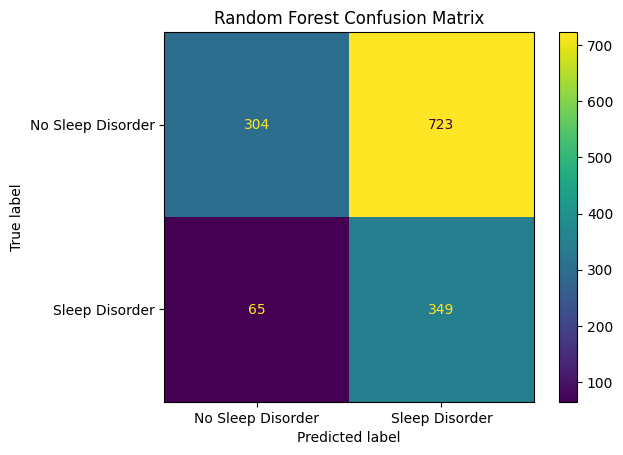

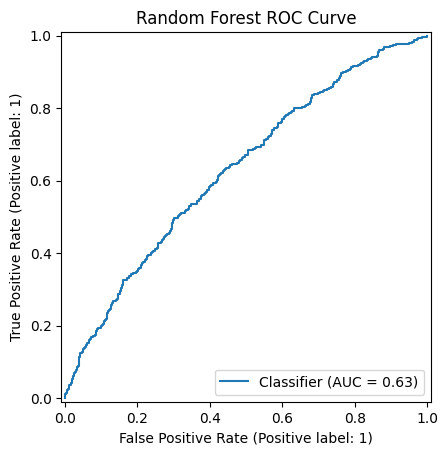

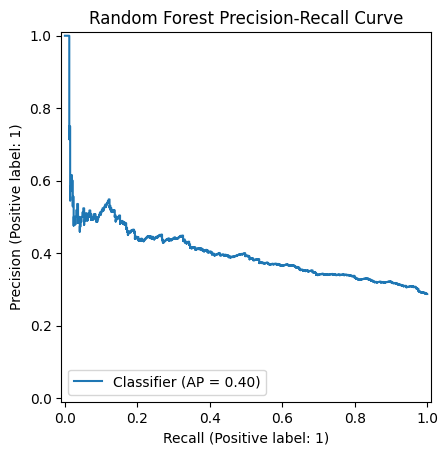

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,AUROC,AUPRC,TN,FP,FN,TP
0,Random Forest,0.4,0.453158,0.569501,0.32556,0.842995,0.296008,0.469717,0.630049,0.403741,304,723,65,349


In [128]:
rf_results, rf_model, rf_proba = evaluate_model(
    model=best_models["Random Forest"],
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest",
    threshold=0.40
)

rf_results_df = pd.DataFrame([rf_results])

rf_results_df

The Random Forest model demonstrated limited but significant predictive performance for sleep disorder classification. The model showed high sensitivity for the sleep disorder class, correctly identifying 84% of participants with sleep disorder. However, this came with low precision, indicating a high number of false positives. The model correctly classified 349 sleep disorder cases but incorrectly classified 723 no-sleep-disorder cases as sleep disorder. Overall, the results suggest that the selected predictors contain some signal related to sleep disorder, but they are not sufficient for highly accurate classification. Therefore, the model may be useful for exploratory analysis or identifying broad patterns, but it should not be interpreted as a reliable individual-level diagnostic tool.

SHAP Plot & feature Importance Plot

The model was not strong enough for high-confidence individual-level prediction, but feature-importance analysis can still help identify which variables contributed most to sleep disorder classification.

### SHAP Analysis

In [129]:
# SHAP and feature importance libraries

# Feature Importance for Random Forest

classifier = rf_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": classifier.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df.head(15))

,Feature,Importance
3,Waist Circumference (cm),0.195009
0,Age,0.180354
2,BMI (kg/m^2),0.140863
11,HS C-Reactive Protein (mg/L),0.076543
7,Sedentary Minutes,0.053964
14,GGT (U/L),0.049978
16,Average_Diastolic_BP (mmHg),0.045458
15,Average_Systolic_BP (mmHg),0.045041
8,Glycohemoglobin (%),0.044324
10,Total Cholesterol (mg/dL),0.037592


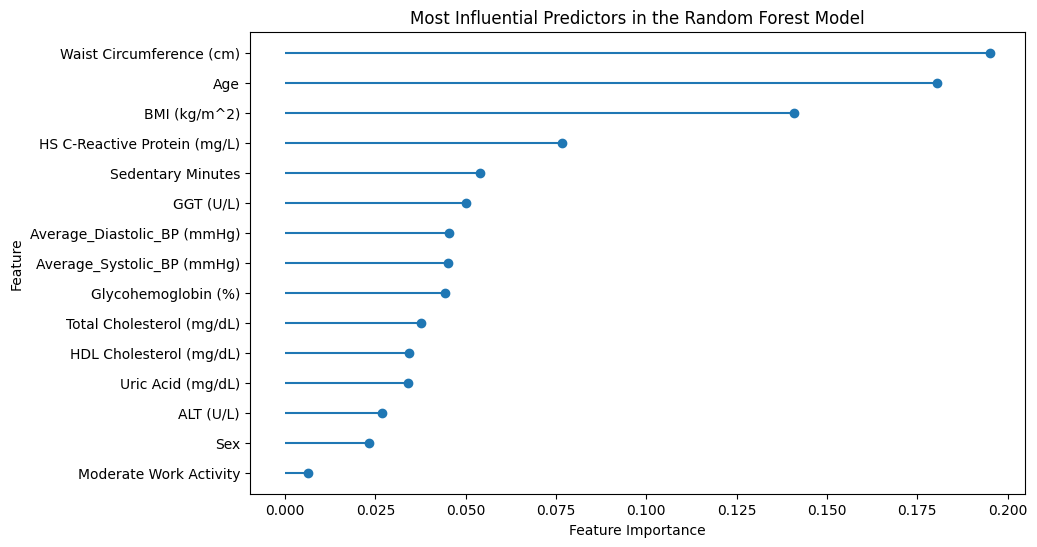

In [130]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.hlines(
    y=top_features["Feature"],
    xmin=0,
    xmax=top_features["Importance"]
)

plt.scatter(
    top_features["Importance"],
    top_features["Feature"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Most Influential Predictors in the Random Forest Model")

plt.show()

This feature importance plot shows which variables contributed most to the Random Forest model’s predictions of sleep disorder status.

The most important predictors were:

1. Waist Circumference
2. Age
3. BMI
4. HS C-Reactive Protein
5. Sedentary Minutes

This suggests that the model relied most heavily on body composition, age, inflammation, and sedentary behavior when classifying whether someone had a sleep disorder.

The strongest feature was waist circumference, followed closely by age and BMI. This means that body-size and adiposity-related measures were especially influential in the model. This makes sense in the context of your project because sleep problems are often connected with broader cardiometabolic health patterns.

HS C-Reactive Protein was also important. Since this is an inflammation marker, its importance suggests that inflammatory status may help distinguish participants with and without sleep disorder in the model.

Sedentary minutes also contributed meaningfully, suggesting that lifestyle and activity patterns may contain useful information for predicting sleep disorder status.

Blood pressure, glycohemoglobin, cholesterol, GGT, uric acid, ALT, and sex also contributed, but less strongly than the top body composition and age-related predictors. Moderate work activity had very low importance, meaning it contributed little to the model’s predictions compared with the other features.

## Unsupervised Learning

#### Prepare Data for Clustering







In [131]:
# Our cluster variables will be the mec features
no_id = [col for col in mec_features if col != "ID"]
X_cluster = cardio_met[no_id]

# Scale before clustering to standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(X_cluster)

#### K-Means Clustering

In [132]:
set(cardio_met.columns) - set(mec_features)

{'MEC Weight', 'PSU', 'Stratum'}

In [133]:
# Create elbow plot for different k cluster values

inert = []

# Try a range of k values
for k in range (3,10):

  mod = KMeans(n_clusters=k, random_state=42,n_init=20)
  mod.fit(scaled)
  inert.append(mod.inertia_)

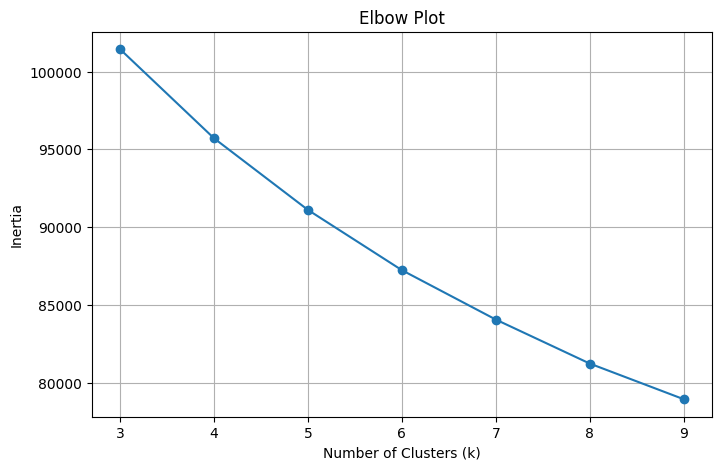

In [134]:
# Elbow plot for k values
plt.figure(figsize=(8,5))
plt.plot(range(3,10), inert, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot')

plt.grid(True)
plt.show()

In [135]:
# Silhouette Scores

scores = []

# for k values between 2 and 20
for k in range (3,10):

  mod = KMeans(n_clusters=k, random_state=42, n_init=20)
  labels = mod.fit_predict(scaled)
  scores.append(silhouette_score(scaled, labels))

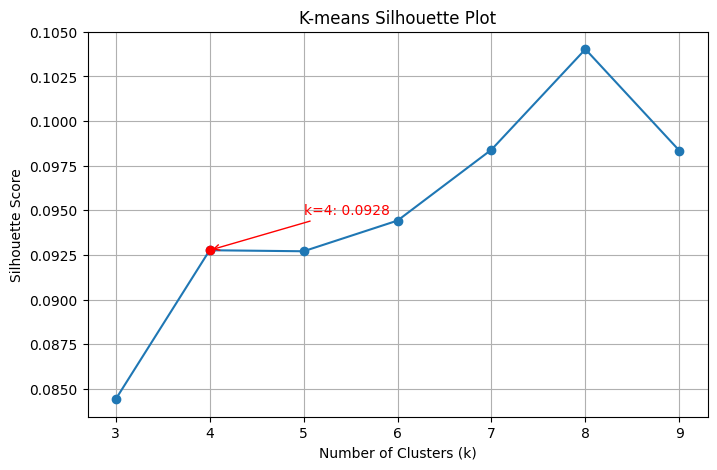

In [136]:
# K-means silhouette Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(3, 10), scores, marker='o')

# We chose k=4
k_label = 4
sil_score = scores[k_label - 3]

# Label the k we chose
ax.annotate(f'k=4: {sil_score:.4f}',
            xy=(k_label, sil_score),
            xytext=(k_label + 1, sil_score + 0.002),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)
ax.scatter([k_label], [sil_score], color='red', zorder=5)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K-means Silhouette Plot')
ax.grid(True)
plt.show()

In [137]:
# Set k based on silhouette and elbow plots, fit model
k = 4
mod = KMeans(n_clusters=k, random_state=42)

# Create phenotype feature
cardio_met["Phenotype"] = mod.fit_predict(scaled)

#### Test Cluster Stability

In [138]:
# Test cluster initialization stability by comparing two datasets (resampled from original)
# and creating two k-means models each with k clusters but with different
# initializations.

# this tests initialization sability

# Across 100 iterations
n_its = 100
ari_scores = []

for i in range(n_its):
    # create fake dataset
    X_boot = resample(scaled, replace=True, random_state=i)

    # Fit model a
    mod_a = KMeans(n_clusters=k, random_state=i, n_init=20)
    labels_a = mod_a.fit_predict(X_boot)

    # Fit model b
    mod_b = KMeans(n_clusters=k, random_state=i+1000, n_init=20)
    labels_b = mod_b.fit_predict(X_boot)

    # Compare model a and b labels
    ari = adjusted_rand_score(labels_a, labels_b)
    ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print(f"Mean ARI: {mean_ari:.3f} ± {std_ari:.3f}")

Mean ARI: 0.972 ± 0.031


In [139]:
# Test data stability
# Take a random subset of 80% of the data, see if resulting cluster
# memberships are the same

# Run 100 iterations
n_its = 100
ari_scores = []

# Original labels
labels = cardio_met["Phenotype"].values

for i in range(n_its):
  # Sample 80% of the original data
  idx = np.random.choice(len(scaled), size=int(0.8 * len(scaled)), replace=False)
  X_sub = scaled[idx]

  # Fit new model ONLY on subset
  s_mod = KMeans(n_clusters=k, random_state=i, n_init=20)
  sub_labels = s_mod.fit_predict(X_sub)

  # Compare subset and original labels of those in the subset
  ari = adjusted_rand_score(labels[idx], sub_labels)
  ari_scores.append(ari)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)

print(f"Mean ARI: {mean_ari:.3f} ± {std_ari:.3f}")

Mean ARI: 0.910 ± 0.039


### Hierarchical Clustering

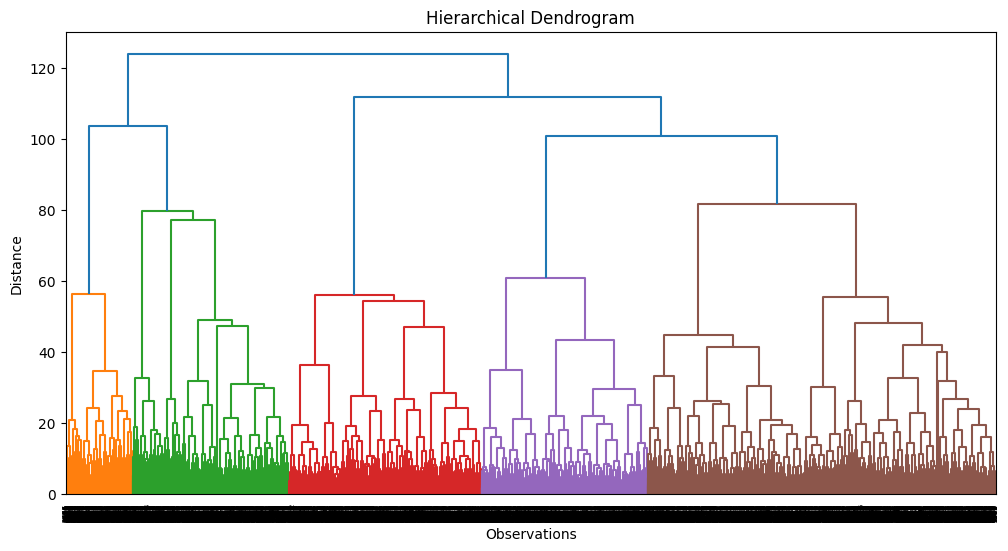

In [140]:
# Hierarchical clustering
Z = linkage(scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z, color_threshold=90)
plt.title("Hierarchical Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In [141]:
# Silhouette scores for hierarchical
k=5
scores_h = []
for k in range(3,10):
  mod = AgglomerativeClustering(n_clusters=k, linkage='ward')
  labels = mod.fit_predict(scaled)
  scores_h.append(silhouette_score(scaled, labels))

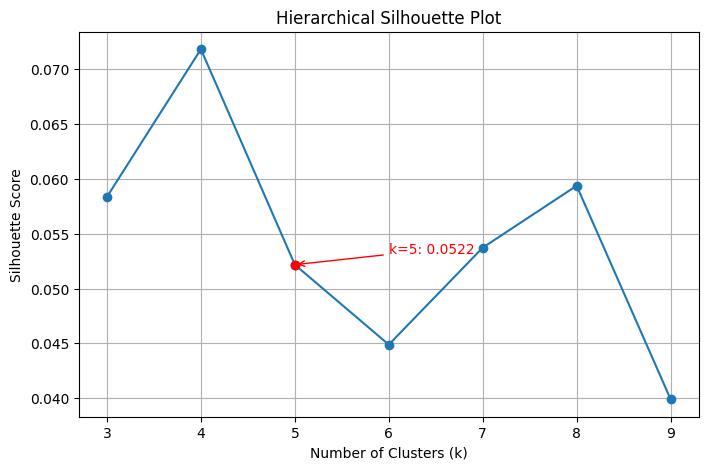

In [142]:
# plot the silhouette score and label of k to be used
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(3, 10), scores_h, marker='o')

# We chose k=5
k_label = 5
sil_score = scores_h[k_label - 3]

ax.annotate(f'k=5: {sil_score:.4f}',
            xy=(k_label, sil_score),
            xytext=(k_label + 1, sil_score + 0.001),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

ax.scatter([k_label], [sil_score], color='red', zorder=5)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Silhouette Plot')
ax.grid(True)
plt.show()

In [143]:
# Final hierarchical model
k= 5
hier_mod = AgglomerativeClustering(n_clusters=k, linkage='ward')
cardio_met["Phenotype_H"] = hier_mod.fit_predict(scaled)

# Examine cluster size
cardio_met["Phenotype_H"].value_counts()

,count
Phenotype_H,
0,2695
2,1490
4,1289
1,1211
3,522


In [144]:
summary_hier = (cardio_met.groupby("Phenotype_H").mean(numeric_only=True))
summary_hier

,ID,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),...,HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg),MEC Weight,PSU,Stratum,Phenotype
Phenotype_H,,,,,,,,,,,,,,,,,,,,,
0,117188.225603,59.186642,0.487941,28.256387,98.737477,1.939147,1.640074,1.834508,334.831169,5.762078,...,2.676575,5.371688,19.096475,25.290538,131.530427,76.162090,28035.093805,1.552876,160.218182,0.637848
1,116845.314616,53.438481,0.371594,37.605509,118.543683,1.867878,1.681255,1.850537,384.146986,6.799092,...,8.631113,5.698183,20.627581,30.930239,124.511836,75.977567,26052.281202,1.516928,160.123865,2.262593
2,117256.819463,43.341611,0.663087,29.865530,100.352617,1.048322,1.159060,1.684564,267.946309,5.580604,...,3.015336,5.506846,21.310738,25.203356,120.910738,73.674720,31179.490899,1.526174,160.073826,1.540268
3,116962.726054,46.43295,0.693487,30.649080,103.789272,1.766284,1.576628,1.756705,327.814176,5.738889,...,3.485958,6.068199,53.348659,95.039464,126.485632,78.510536,26888.377157,1.565134,160.480843,1.871648
4,117202.904577,32.416602,0.363072,25.212568,86.341971,1.996897,1.698216,1.640031,375.155935,5.277657,...,2.120760,4.733592,15.853375,17.354538,109.648694,67.703388,31771.963017,1.565555,160.863460,1.017067


In [145]:
# ARI between k-means and hierarchical
ari_between = adjusted_rand_score(cardio_met["Phenotype_H"], cardio_met["Phenotype"])
ari_between

0.29282241201093695

In [146]:
# Test data stability HIERARCHICAL
# Take a random subset of 80% of the data, see if resulting cluster
# memberships are the same

n_its = 100
ari_scores = []
labels = cardio_met["Phenotype_H"].values

for i in range(n_its):
  idx = np.random.choice(len(scaled), size=int(0.8 * len(scaled)), replace=False)

  X_sub = scaled[idx]

  # Fit new model ONLY on subset
  s_mod = AgglomerativeClustering(n_clusters=5, linkage='ward')
  sub_labels = s_mod.fit_predict(X_sub)

  # Compare subset and original labels
  ari = adjusted_rand_score(labels[idx], sub_labels)
  ari_scores.append(ari)


print(f"Mean ARI: {np.mean(ari_scores):.3f} ± {np.std(ari_scores):.3f}")

Mean ARI: 0.235 ± 0.081


#### Cluster Profile Summary

Hierarchical clustering performs worse than k-means in terms of data stability and silhouette scores. The final clustering model to create phenotypes will use k-means.

In [147]:
# Cluster summaries

summary = cardio_met.groupby("Phenotype").mean(numeric_only=True)
summary = summary[no_id]

summary


,Age,Sex,BMI (kg/m^2),Waist Circumference (cm),Vigorous Work Activity,Moderate Work Activity,Walk or Bicycle for Transportation,Sedentary Minutes,Glycohemoglobin (%),HDL Cholesterol (mg/dL),Total Cholesterol (mg/dL),HS C-Reactive Protein (mg/L),Uric Acid (mg/dL),ALT (U/L),GGT (U/L),Average_Systolic_BP (mmHg),Average_Diastolic_BP (mmHg)
Phenotype,,,,,,,,,,,,,,,,,
0,64.576279,0.449072,27.573789,97.652196,1.907198,1.732911,1.796741,325.081485,5.959756,58.186962,194.590312,2.586806,5.304844,17.675871,24.485740,137.019617,76.778708
1,35.038121,0.378546,25.296809,86.876020,1.695035,1.481826,1.709220,317.091755,5.325887,56.919770,172.898936,2.189227,4.613564,16.264184,17.887979,110.230940,67.465056
2,46.024306,0.904861,31.405992,106.792431,1.503472,1.366667,1.711806,325.252083,5.831528,45.350694,195.281250,3.020995,6.397500,38.436111,57.947639,127.953356,80.198958
3,51.347158,0.333333,39.542218,122.246544,1.800307,1.579109,1.870968,399.139785,6.373656,46.516129,175.547619,8.992663,5.770046,19.504608,28.616928,120.712622,75.269841


In [148]:
# Examine cluster sizes

cardio_met["Phenotype"].value_counts()

,count
Phenotype,
1,2256
0,2209
2,1440
3,1302


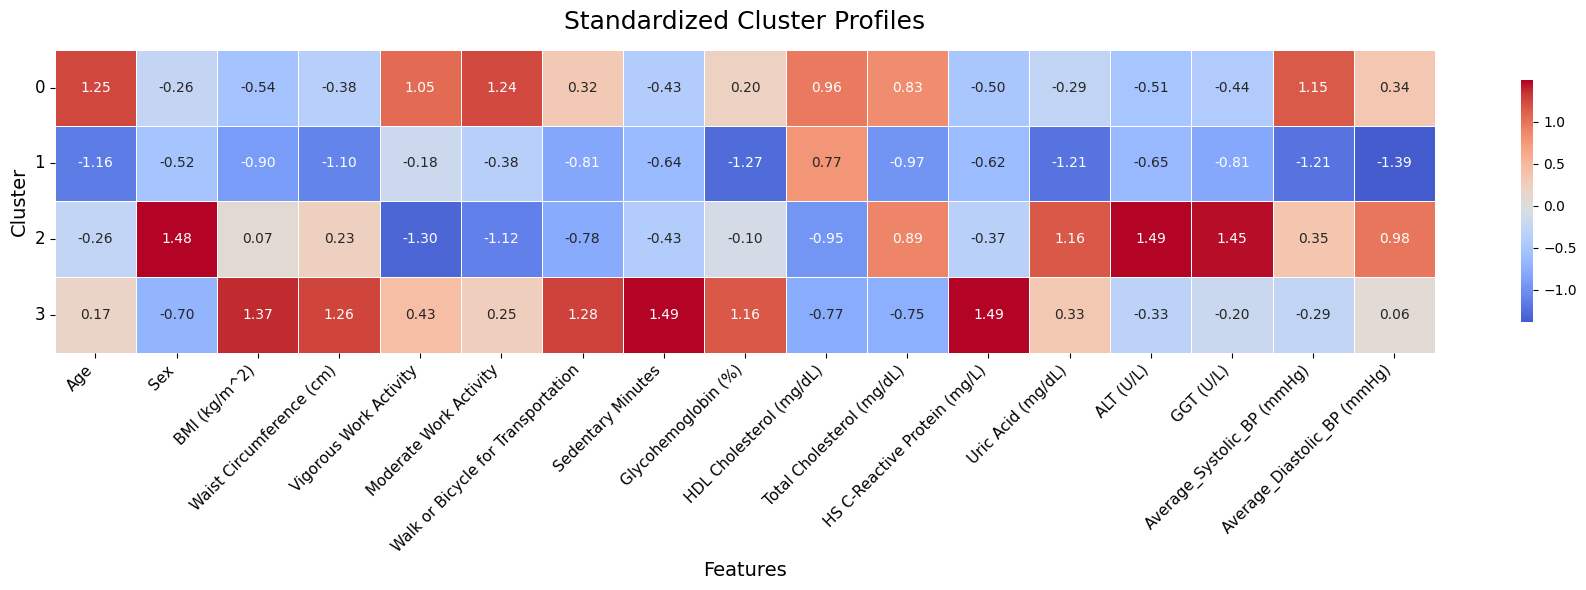

In [149]:
# create SCALED heat map to visualize cluster characteristics
# scale before heat map since the features are on different scales
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize cluster profiles
cluster_scaled = (summary - summary.mean()) / summary.std()
cluster_scaled = cluster_scaled.astype(float)

plt.figure(figsize=(18, 6))
ax = sns.heatmap(
    cluster_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size":10},
    cbar_kws={"shrink":0.8}
)

ax.set_title("Standardized Cluster Profiles", fontsize=18, pad=15)

ax.set_xlabel("Features", fontsize=14)
ax.set_ylabel("Cluster", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

#### PCA Visualization

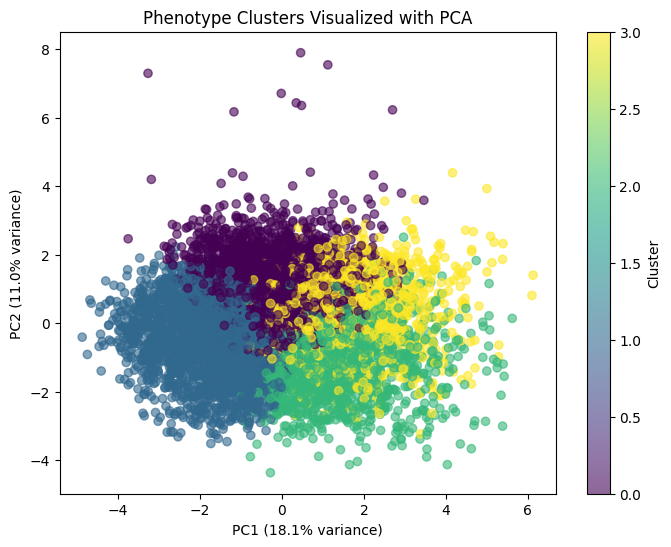

In [150]:
# Visualize clusters using pca
# Do the clusters separate in a meaningful way in the largest directions of variation?

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled)
plt.figure(figsize=(8,6))

# Color is the phenotype group
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cardio_met["Phenotype"],
    alpha=0.6
)

# Label pc1 and pc2 with their percent variance explained
plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)"
)

plt.title("Phenotype Clusters Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


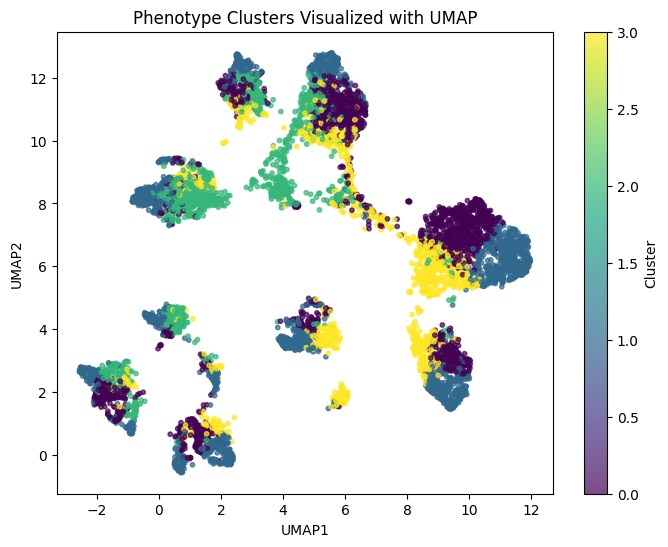

In [151]:
# Compressing into 2D space for cluster visualization.
# UMPA preserves local structure, points that are close to eachother in the high
# dimensional space of our cluster components will be close together in this
# 2D projection.
umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap.fit_transform(scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cardio_met["Phenotype"],
    cmap="viridis",
    alpha=0.7,
    s=10
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Phenotype Clusters Visualized with UMAP")
plt.colorbar(label="Cluster")
plt.show()

#### Interpret Lifestyle Phenotypes

Phenotype 0 (Age / BP driven risk): This group has the highest average age at about 64.6 years. The average systolic BP is the highest among groups but the group has a moderate average dystolic BP. This group has relatively low sedentary minutes and the least amount of vigorous and moderate work activity.

Phenotype 1 (Good cardiometabolic health, young): This is the youngest group with average age of 35.0 years. This group also has the lowest BMI and waist circumference on average. The average blood pressures are healthy and this group has the lowest average glycohemoglobin, HS-CRP, and total cholesterol.

Phenotype 2 (Metabolic/ Liver Risk): Middle aged with average of 46.0, 90% male, BMI 31.4 (Class 1 obesity), waist circumference 107 cm. ALT and GGT are both clearly the highest on average in this phenotype, suggesting hepatic involvement. This group also has the highest amount of moderate and vigorous work intensity across groups (survey answers encoded 1 for yes, work involved moderate/vigorous work and 2 for no).

Phenotype 3 (Obsese, cardiometabolic risk): This group is late-middle aged with average age of 51.3 years. This group has the highest average BMI and sedentary minutes, and lowest work avtivity. This group has an extremely high HS-CRP of around 8.99 while other groups all have levels around 2-3. The glycohemoglobin is also significantly higher than the other groups at 6.37 on average, close to the levels of those with type 2 diabetes wich is 6.5%.

### Supervised Model with Phenotype Feature

In [152]:
# Supervised model with phenotype feature

phenotype_col = "Phenotype"
target_col = "SLQ050"

if phenotype_col not in cardio_met.columns:
    raise KeyError(f"'{phenotype_col}' was not found in cardio_met.")

# Start from cardio_met, which now includes the k-means phenotype labels
sl_pheno_df = cardio_met.copy()

# Add sleep outcome
sleep_outcome = master_df[["SEQN", target_col]].copy()
sleep_outcome = sleep_outcome.rename(columns={"SEQN": "ID"})

sl_pheno_df = sl_pheno_df.merge(
    sleep_outcome,
    on="ID",
    how="inner"
)

# Keep valid sleep outcome responses only
sl_pheno_df = sl_pheno_df[sl_pheno_df[target_col].isin([1, 2])].copy()

# Recode outcome
sl_pheno_df[target_col] = sl_pheno_df[target_col].map({
    1: 1,  # Sleep disorder
    2: 0   # No sleep disorder
})

# Add phenotype to the original supervised feature set
sl_pheno_features = [col for col in mec_features if col != "ID"] + [phenotype_col]

# Treat phenotype as categorical so it gets one-hot encoded
sl_pheno_df[phenotype_col] = sl_pheno_df[phenotype_col].astype("category")

# Create X and y
X_pheno = sl_pheno_df[sl_pheno_features]
y_pheno = sl_pheno_df[target_col]

In [153]:
print("Dataset Summary With Phenotype:")
print(f"Observations: {len(sl_pheno_df):,}")
print(f"Predictors: {len(sl_pheno_features)}")
print(f"\nX shape: {X_pheno.shape}")
print(f"y shape: {y_pheno.shape}")

Dataset Summary With Phenotype:
Observations: 7,204
Predictors: 18

X shape: (7204, 18)
y shape: (7204,)


In [154]:
# Train/test split for phenotype model

X_train_pheno, X_test_pheno, y_train_pheno, y_test_pheno = test_train_split(
    X_pheno,
    y_pheno
)

# Create preprocessor and models
preprocessor_pheno, _, _ = preprocessor_pipeline(X_pheno)

models_pheno = supervisedlearning_models(preprocessor_pheno)

# Run GridSearchCV for models with phenotype feature
best_models_pheno = gridsearch_models(
    models=models_pheno,
    X_train=X_train_pheno,
    y_train=y_train_pheno,
    cv=5,
    scoring="f1"
)

Train: (5763, 18)
Test: (1441, 18)

Best Random Forest Parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV Score (f1): 0.466

Best XGBoost Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best CV Score (f1): 0.246



Random Forest + Phenotype Classification Report
              precision    recall  f1-score   support

           0       0.83      0.30      0.44      1027
           1       0.33      0.85      0.47       414

    accuracy                           0.45      1441
   macro avg       0.58      0.57      0.45      1441
weighted avg       0.68      0.45      0.45      1441



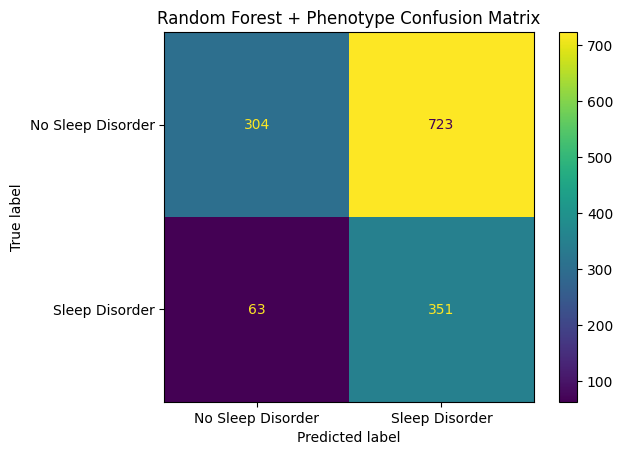

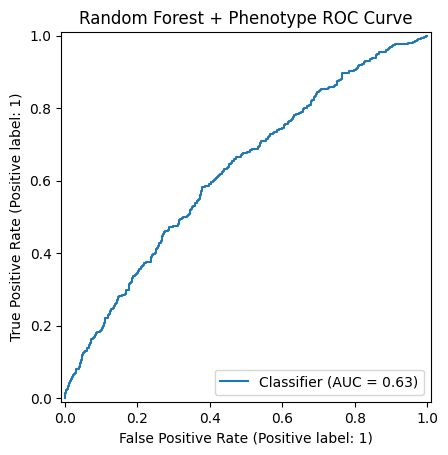

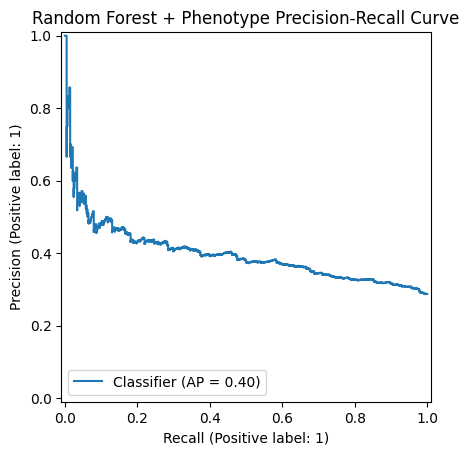

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,AUROC,AUPRC,TN,FP,FN,TP
0,Random Forest + Phenotype,0.4,0.455,0.572,0.327,0.848,0.296,0.472,0.626,0.399,304,723,63,351


In [155]:
# Evaluate Random Forest with phenotype feature

rf_pheno_results, rf_pheno_model, rf_pheno_proba = evaluate_model(
    model=best_models_pheno["Random Forest"],
    X_train=X_train_pheno,
    X_test=X_test_pheno,
    y_train=y_train_pheno,
    y_test=y_test_pheno,
    model_name="Random Forest + Phenotype",
    threshold=0.40
)

rf_pheno_results_df = pd.DataFrame([rf_pheno_results]).round(3)

display(rf_pheno_results_df)

In [156]:
# Compare baseline Random Forest vs Random Forest with phenotype

baseline_rf_results = rf_results_df.copy()
baseline_rf_results["Feature Set"] = "Baseline"

phenotype_rf_results = rf_pheno_results_df.copy()
phenotype_rf_results["Feature Set"] = "Baseline + Phenotype"

rf_comparison_df = pd.concat(
    [baseline_rf_results, phenotype_rf_results],
    ignore_index=True
)

rf_comparison_df = rf_comparison_df[
    [
        "Model",
        "Feature Set",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "AUROC",
        "AUPRC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(rf_comparison_df.round(3))

,Model,Feature Set,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,AUROC,AUPRC,TN,FP,FN,TP
0,Random Forest,Baseline,0.453,0.570,0.326,0.843,0.296,0.470,0.630,0.404,304,723,65,349
1,Random Forest + Phenotype,Baseline + Phenotype,0.455,0.572,0.327,0.848,0.296,0.472,0.626,0.399,304,723,63,351


In [157]:
# Feature importance for Random Forest + Phenotype

preprocessor_pheno_fitted = rf_pheno_model.named_steps["preprocessor"]
classifier_pheno = rf_pheno_model.named_steps["classifier"]

# Get transformed feature names
feature_names_pheno = preprocessor_pheno_fitted.get_feature_names_out()

# Clean feature names
clean_feature_names_pheno = (
    pd.Series(feature_names_pheno)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Make phenotype labels cleaner
clean_feature_names_pheno = clean_feature_names_pheno.str.replace(
    "Phenotype ",
    "Phenotype ",
    regex=False
)

# Create feature importance dataframe
feature_importance_pheno_df = pd.DataFrame({
    "Feature": clean_feature_names_pheno,
    "Importance": classifier_pheno.feature_importances_
})

feature_importance_pheno_df = feature_importance_pheno_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_pheno_df.head(15))

,Feature,Importance
3,Waist Circumference (cm),0.183036
0,Age,0.160038
2,BMI (kg/m^2),0.120720
11,HS C-Reactive Protein (mg/L),0.062774
14,GGT (U/L),0.048119
7,Sedentary Minutes,0.046772
15,Average Systolic BP (mmHg),0.046311
16,Average Diastolic BP (mmHg),0.043032
18,Phenotype 1,0.039850
8,Glycohemoglobin (%),0.036795


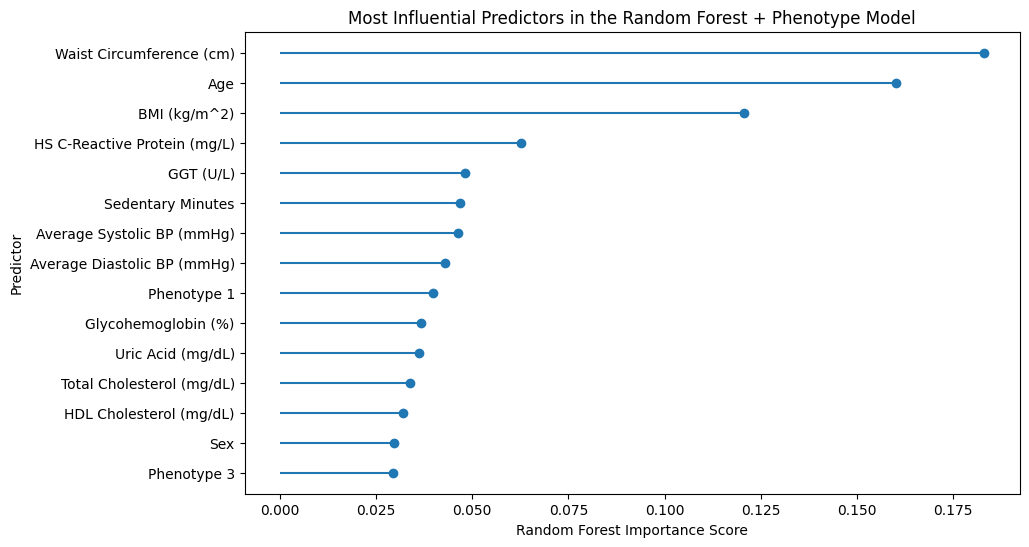

In [158]:
# Lollipop plot for Random Forest + Phenotype feature importance

top_features_pheno = feature_importance_pheno_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.hlines(
    y=top_features_pheno["Feature"],
    xmin=0,
    xmax=top_features_pheno["Importance"]
)

plt.scatter(
    top_features_pheno["Importance"],
    top_features_pheno["Feature"]
)

plt.xlabel("Random Forest Importance Score")
plt.ylabel("Predictor")
plt.title("Most Influential Predictors in the Random Forest + Phenotype Model")

plt.show()